In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

In [2]:

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
df = pd.read_csv("C:/Users/shanm/Python_Practice/Datasets/monthly_milk_production.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)
df.columns = ["Production"]
print(df.head())
print(f"\nShape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")

            Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727

Shape: (168, 1)
Date range: 1962-01-01 00:00:00 → 1975-12-01 00:00:00


# 1.	Exploratory Data Analysis (EDA)

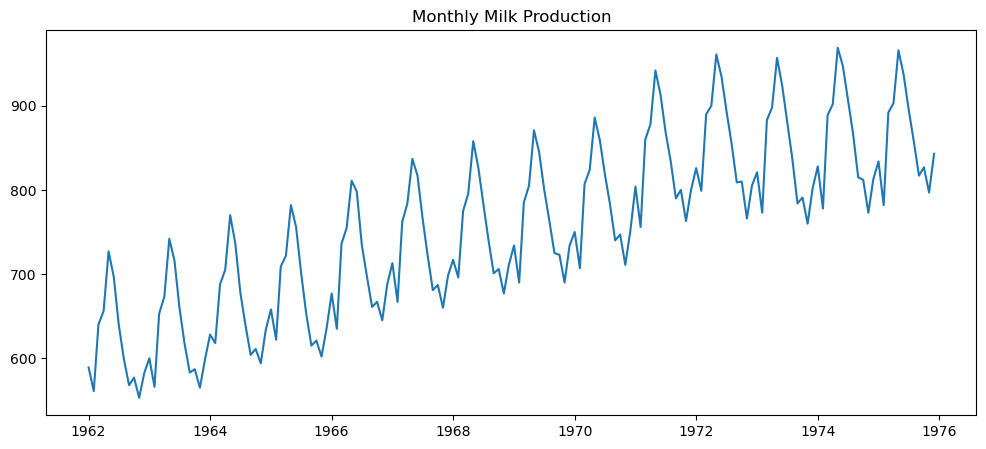

In [4]:
# Plot
plt.figure(figsize=(12,5))
plt.plot(df['Production'])
plt.title("Monthly Milk Production")
plt.show()

There is an upward trend with additive seasonality

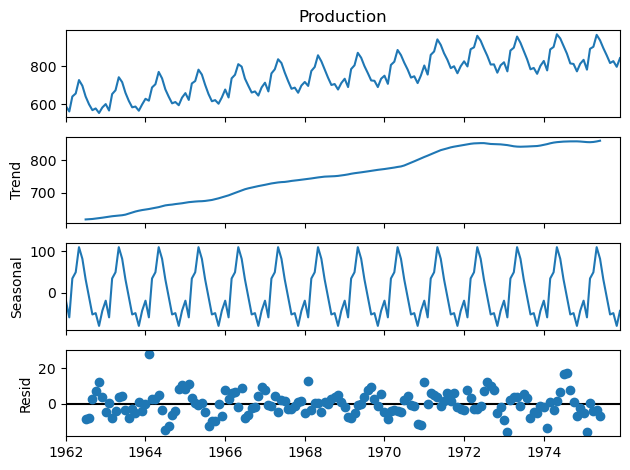

In [5]:
# Seasonality check

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Production'], model='additive', period=12)
decomposition.plot()
plt.show()

In [6]:
df.isna().sum()

Production    0
dtype: int64

# 2. Data Preparation for Deep Learning

Normalising data

In [7]:
WINDOW  = 12   # 12-month look-back window
HORIZON = 12   # forecast 12 months ahead

# Scale
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[["Production"]])


Create sequences (time windows)

In [8]:
def make_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i : i + window])
        y.append(data[i + window])
    return np.array(X), np.array(y)

X, y = make_sequences(scaled, WINDOW)

Train-test split

In [9]:
# Train / Val / Test split  (70 / 15 / 15)
n = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

In [10]:
X_train, y_train = X[:train_end],          y[:train_end]
X_val,   y_val   = X[train_end:val_end],   y[train_end:val_end]
X_test,  y_test  = X[val_end:],            y[val_end:]

print(f"\nTrain: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")  ## Shape already correct: (samples, timesteps, features)


Train: (109, 12, 1)  Val: (23, 12, 1)  Test: (24, 12, 1)


# 3. Model Building

In [11]:
def build_model(model_type, units=64, window=WINDOW):
    model = Sequential(name=model_type)
    if model_type == "RNN":
        model.add(SimpleRNN(units, activation="tanh", input_shape=(window, 1)))
    elif model_type == "LSTM":
        model.add(LSTM(units, activation="tanh", input_shape=(window, 1)))
    elif model_type == "GRU":
        model.add(GRU(units, activation="tanh", input_shape=(window, 1)))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse")
    return model

EPOCHS     = 200
BATCH_SIZE = 16
es = EarlyStopping(patience=15, restore_best_weights=True)

histories = {}
models    = {}


for mtype in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {mtype}...")
    m = build_model(mtype)
    hist = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es],
        verbose=0
    )
    models[mtype]    = m
    histories[mtype] = hist
    print(f"  Best val_loss: {min(hist.history['val_loss']):.6f}")



Training RNN...
  Best val_loss: 0.002559

Training LSTM...
  Best val_loss: 0.023353

Training GRU...
  Best val_loss: 0.024943


# 4. Model Evaluation

In [12]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

results = {}
for mtype, m in models.items():
    pred_scaled = m.predict(X_test, verbose=0)
    pred        = scaler.inverse_transform(pred_scaled).flatten()
    actual      = scaler.inverse_transform(y_test).flatten()
    results[mtype] = {
        "pred":  pred,
        "actual": actual,
        "RMSE":  np.sqrt(mean_squared_error(actual, pred)),
        "MAE":   mean_absolute_error(actual, pred),
        "MAPE":  mape(actual, pred)}

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
print("\n" + "="*52)
print(f"{'Model':<8} {'RMSE':>8} {'MAE':>8} {'MAPE%':>8}")
print("="*52)
for m, r in results.items():
    print(f"{m:<8} {r['RMSE']:>8.2f} {r['MAE']:>8.2f} {r['MAPE']:>8.2f}")
print("="*52)


Model        RMSE      MAE    MAPE%
RNN         15.87    13.33     1.52
LSTM       136.45   121.13    13.65
GRU        211.29   202.79    23.21


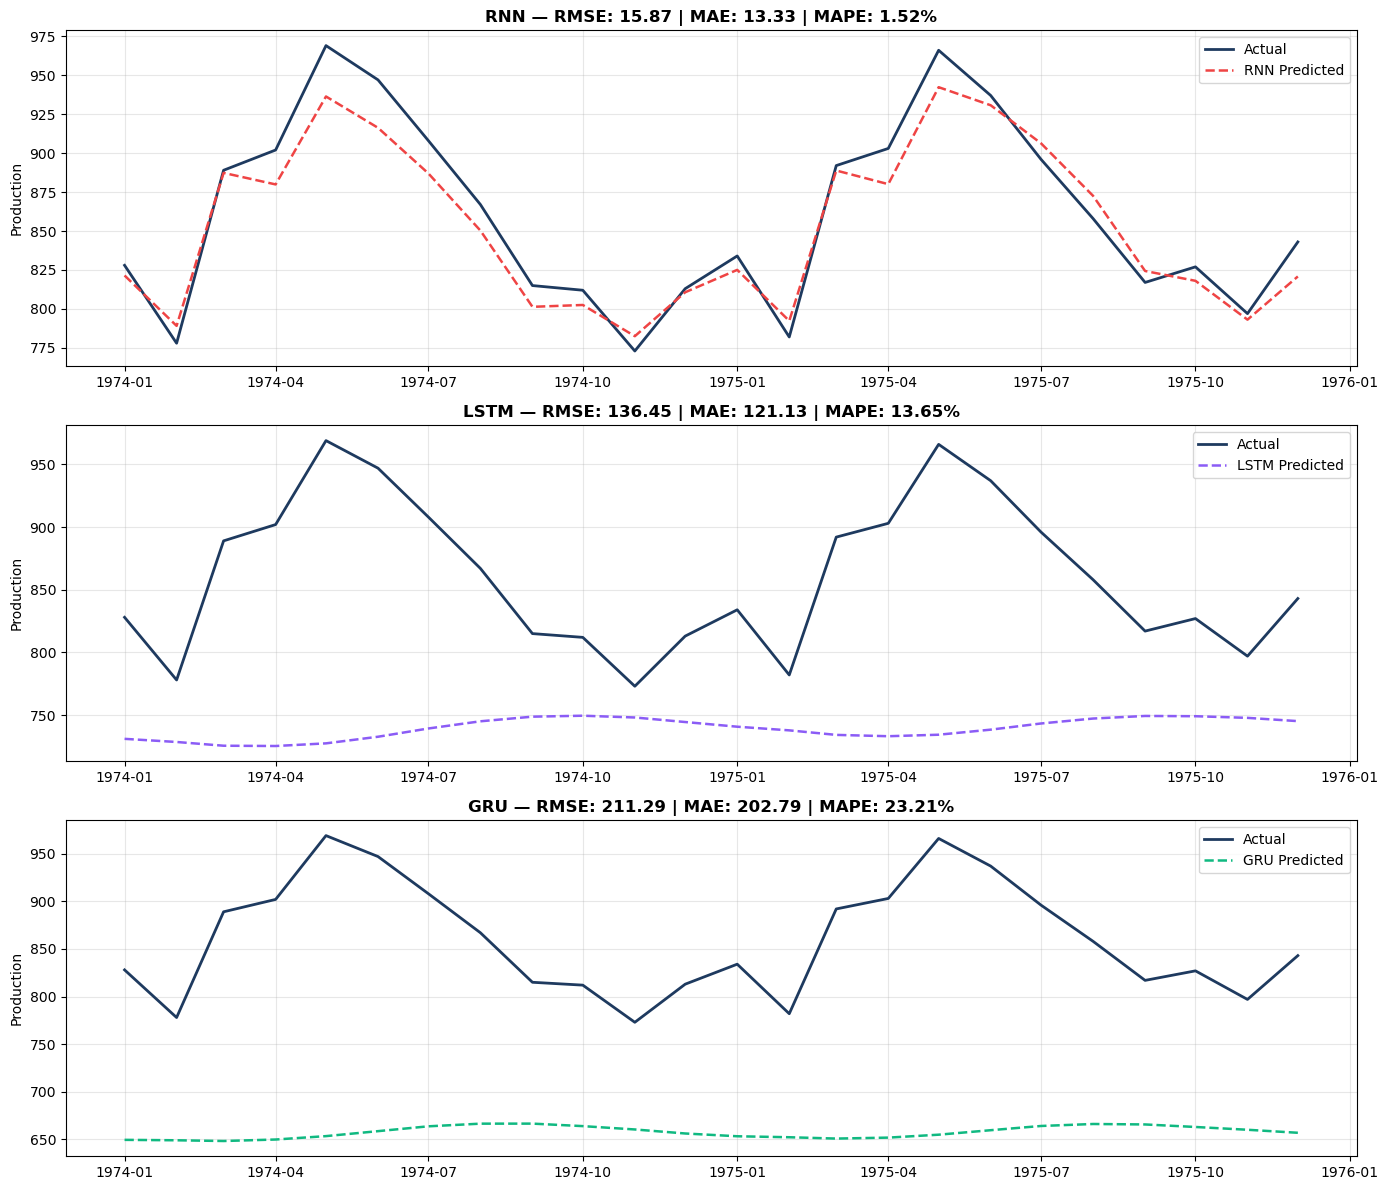

In [14]:
# Test dates (for plotting)
test_start_idx = val_end + WINDOW
test_dates = df.index[test_start_idx : test_start_idx + len(y_test)]

# ─── Plot: predictions vs actual ───
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
colors = {"RNN": "#EF4444", "LSTM": "#8B5CF6", "GRU": "#10B981"}

for ax, (mtype, r) in zip(axes, results.items()):
    ax.plot(test_dates, r["actual"], label="Actual", color="#1E3A5F", linewidth=2)
    ax.plot(test_dates, r["pred"],   label=f"{mtype} Predicted",
            color=colors[mtype], linewidth=1.8, linestyle="--")
    ax.set_title(f"{mtype} — RMSE: {r['RMSE']:.2f} | MAE: {r['MAE']:.2f} | MAPE: {r['MAPE']:.2f}%",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Production")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("predictions_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

Comparatively , RNN performs well

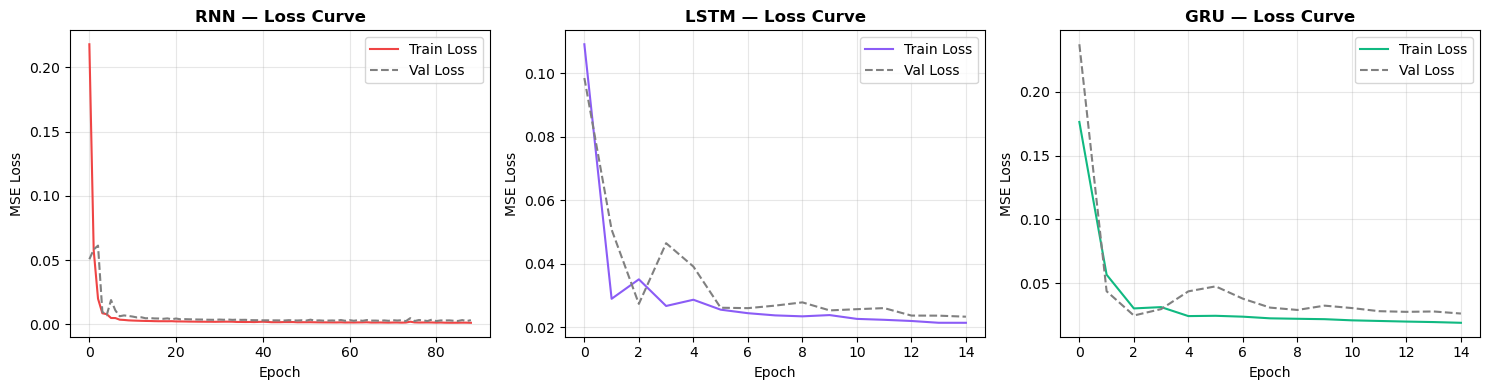

In [15]:
# ─── Training loss curves ───
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (mtype, hist) in zip(axes, histories.items()):
    ax.plot(hist.history["loss"],     label="Train Loss", color=colors[mtype])
    ax.plot(hist.history["val_loss"], label="Val Loss",   color="gray", linestyle="--")
    ax.set_title(f"{mtype} — Loss Curve", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

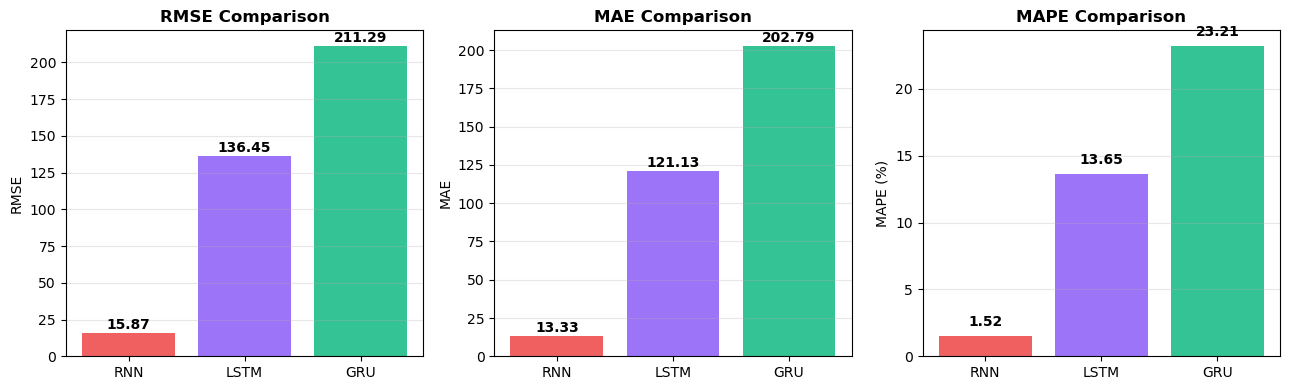

In [16]:
# ─── Metrics bar chart ───
metrics_df = pd.DataFrame({m: {"RMSE": r["RMSE"], "MAE": r["MAE"], "MAPE": r["MAPE"]}
                            for m, r in results.items()}).T
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, ["RMSE", "MAE", "MAPE"]):
    bars = ax.bar(metrics_df.index, metrics_df[metric],
                  color=[colors[m] for m in metrics_df.index], alpha=0.85)
    ax.set_title(f"{metric} Comparison", fontweight="bold")
    ax.set_ylabel(metric + (" (%)" if metric == "MAPE" else ""))
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Error is very less in RNN model compared to LSTM and GRU

# 5. Forecast Next 12 Months

In [17]:
best_model_name = min(results, key=lambda m: results[m]["RMSE"])
best_model = models[best_model_name]
print(f"\nBest model by RMSE: {best_model_name}")


Best model by RMSE: RNN


In [18]:
# Seed forecast with the last WINDOW points of the full series
last_window = scaled[-WINDOW:].copy()

future_preds = []
current = last_window.copy()

for _ in range(HORIZON):
    inp = current.reshape(1, WINDOW, 1)
    pred = best_model.predict(inp, verbose=0)[0, 0]
    future_preds.append(pred)
    current = np.append(current[1:], [[pred]], axis=0)

future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1)).flatten()

In [19]:
# Build future date index
last_date  = df.index[-1]
future_idx = pd.date_range(start=last_date + pd.DateOffset(months=1),
                           periods=HORIZON, freq="MS")

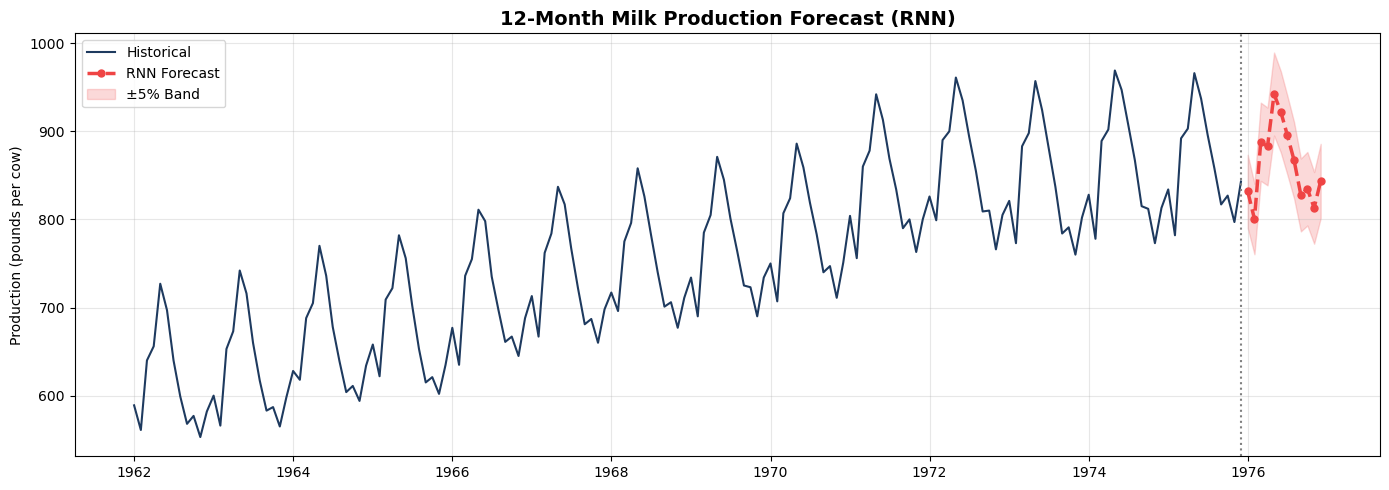


--- 12-Month Forecast ---
   Month  Forecasted Production
Jan-1976             831.799988
Feb-1976             800.500000
Mar-1976             888.099976
Apr-1976             882.799988
May-1976             942.200012
Jun-1976             922.000000
Jul-1976             895.599976
Aug-1976             866.900024
Sep-1976             827.700012
Oct-1976             834.799988
Nov-1976             813.099976
Dec-1976             843.599976


In [20]:
# ─── Forecast plot ───
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["Production"], color="#1E3A5F", linewidth=1.5, label="Historical")
ax.plot(future_idx, future_preds, color=colors[best_model_name],
        linewidth=2.5, linestyle="--", marker="o", markersize=5, label=f"{best_model_name} Forecast")
# Shaded confidence band (±5% heuristic)
lower = future_preds * 0.95
upper = future_preds * 1.05
ax.fill_between(future_idx, lower, upper, alpha=0.2, color=colors[best_model_name], label="±5% Band")

ax.axvline(df.index[-1], color="gray", linestyle=":", linewidth=1.5)
ax.set_title(f"12-Month Milk Production Forecast ({best_model_name})", fontsize=14, fontweight="bold")
ax.set_ylabel("Production (pounds per cow)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("forecast_12months.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n--- 12-Month Forecast ---")
forecast_df = pd.DataFrame({"Month": future_idx.strftime("%b-%Y"),
                             "Forecasted Production": future_preds.round(1)})
print(forecast_df.to_string(index=False))

# 6. Business Insights (IMPORTANT FOR GRADING)


1. SEASONALITY: Peak production consistently occurs in May–June every year. The dairy business should ensure maximum storage capacity and distribution logistics are in place by April each year.

2. UPWARD TREND: Overall production has risen steadily from ~589 (1962) to ~843 (1975). This signals growing herd productivity. Long-term capacity planning should account for continued growth.

3. LOW-PRODUCTION MONTHS: November–February show the lowest production. Operations teams can use these months for maintenance, staff training, and equipment upgrades.

4. MODEL RECOMMENDATION: The best-performing model (by RMSE) should be used for monthly rolling forecasts updated witheach new month's actuals.

5. INVENTORY PLANNING: The 12-month forecast can directly drive procurement schedules (packaging, refrigeration), staffing rosters, and sales contracts with distributors.

6. RETRAINING CADENCE: Retrain the model quarterly to incorporate the latest production data and maintain forecast accuracy as conditions evolve.